# Figure 4 t-SNE Sensitivity Analysis

This notebook isolates the Graphical Lasso t-SNE sensitivity checks from `make_main_figures_revision.ipynb`.

The baseline uses the original Euclidean profile-distance clustering. The later sections change one thing at a time, starting with the feature-profile distance metric.

## Setup

Load the same revision helpers and dataset cache used by the main figure notebook.

In [122]:
from pathlib import Path
import importlib
import sys

import numpy as np
import pandas as pd
from scipy.cluster import hierarchy
from scipy.spatial.distance import pdist
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler
from IPython.display import display

repo_root = Path.cwd()
if repo_root.name == "notebooks":
    repo_root = repo_root.parents[1]

pkg_root = repo_root / "data_synthesis"
if str(pkg_root) not in sys.path:
    sys.path.insert(0, str(pkg_root))

import src.revision.figure4_graphical_lasso_plots as figure4_graphical_lasso_plots
figure4_graphical_lasso_plots = importlib.reload(figure4_graphical_lasso_plots)

from src.revision import config as revision_config
from src.revision import data_io, display as revision_display
from src.revision import figure4_graphical_lasso

EXPORT_DIR = repo_root / "data_synthesis" / "notebooks" / "revision_exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Run mode: {revision_config.RUN_MODE} | CVAE_EPOCHS={revision_config.CVAE_EPOCHS}")

Run mode: final | CVAE_EPOCHS=200


In [123]:
datasets = data_io.require_datasets()
figure4_real_data, figure4_synthetic_data, figure4_feature_names = figure4_graphical_lasso._get_figure4_precision_inputs()

pd.DataFrame({
    "dataset": list(figure4_real_data),
    "n_samples": [figure4_real_data[ds].shape[0] for ds in figure4_real_data],
    "n_features": [figure4_real_data[ds].shape[1] for ds in figure4_real_data],
    "alpha": [figure4_graphical_lasso.FIGURE4_ALPHAS[ds] for ds in figure4_real_data],
})

,dataset,n_samples,n_features,alpha
0,HIV,91,63,0.5040
1,Breast Cancer,569,30,0.5020
2,Diabetes,768,8,0.0159


## Baseline: Euclidean Profile Distance

These are the original supplemental Graphical Lasso t-SNE edge-overlay layouts. The t-SNE coordinates are fit from real partial-correlation profiles, and feature cluster colors use average-linkage hierarchical clustering with Euclidean distance on those same profiles.

c:\Users\tonyt\Desktop\distinguishable_data\.venv\Lib\site-packages\sklearn\covariance\_graph_lasso.py:199: ConvergenceWarning: graphical_lasso: did not converge after 1000 iteration: dual gap: -1.299e-04
  warnings.warn(


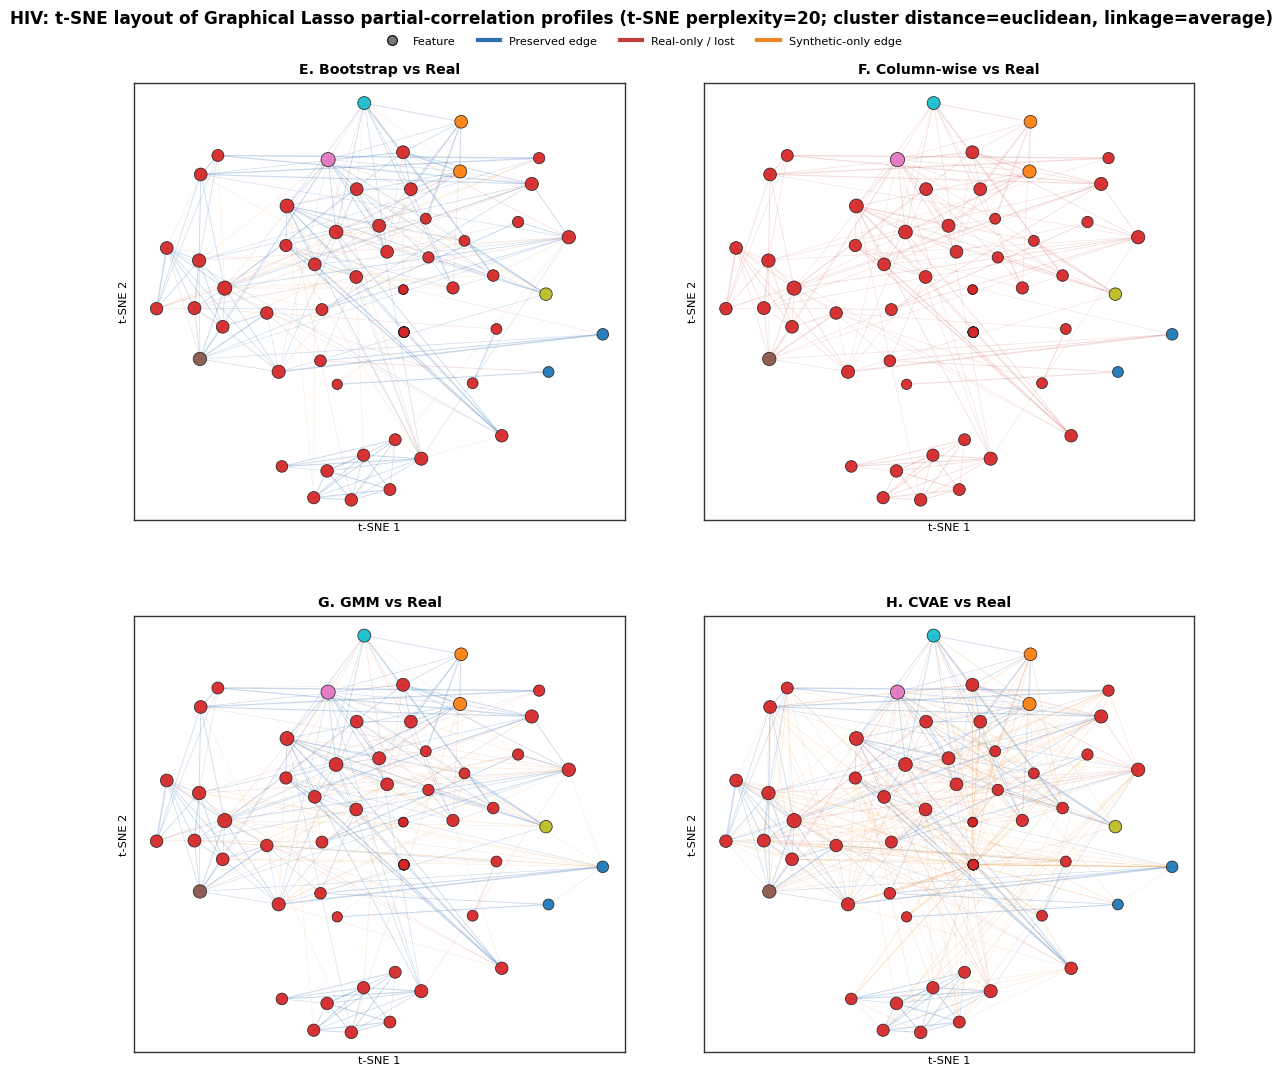

c:\Users\tonyt\Desktop\distinguishable_data\.venv\Lib\site-packages\sklearn\covariance\_graph_lasso.py:199: ConvergenceWarning: graphical_lasso: did not converge after 1000 iteration: dual gap: -1.299e-04
  warnings.warn(


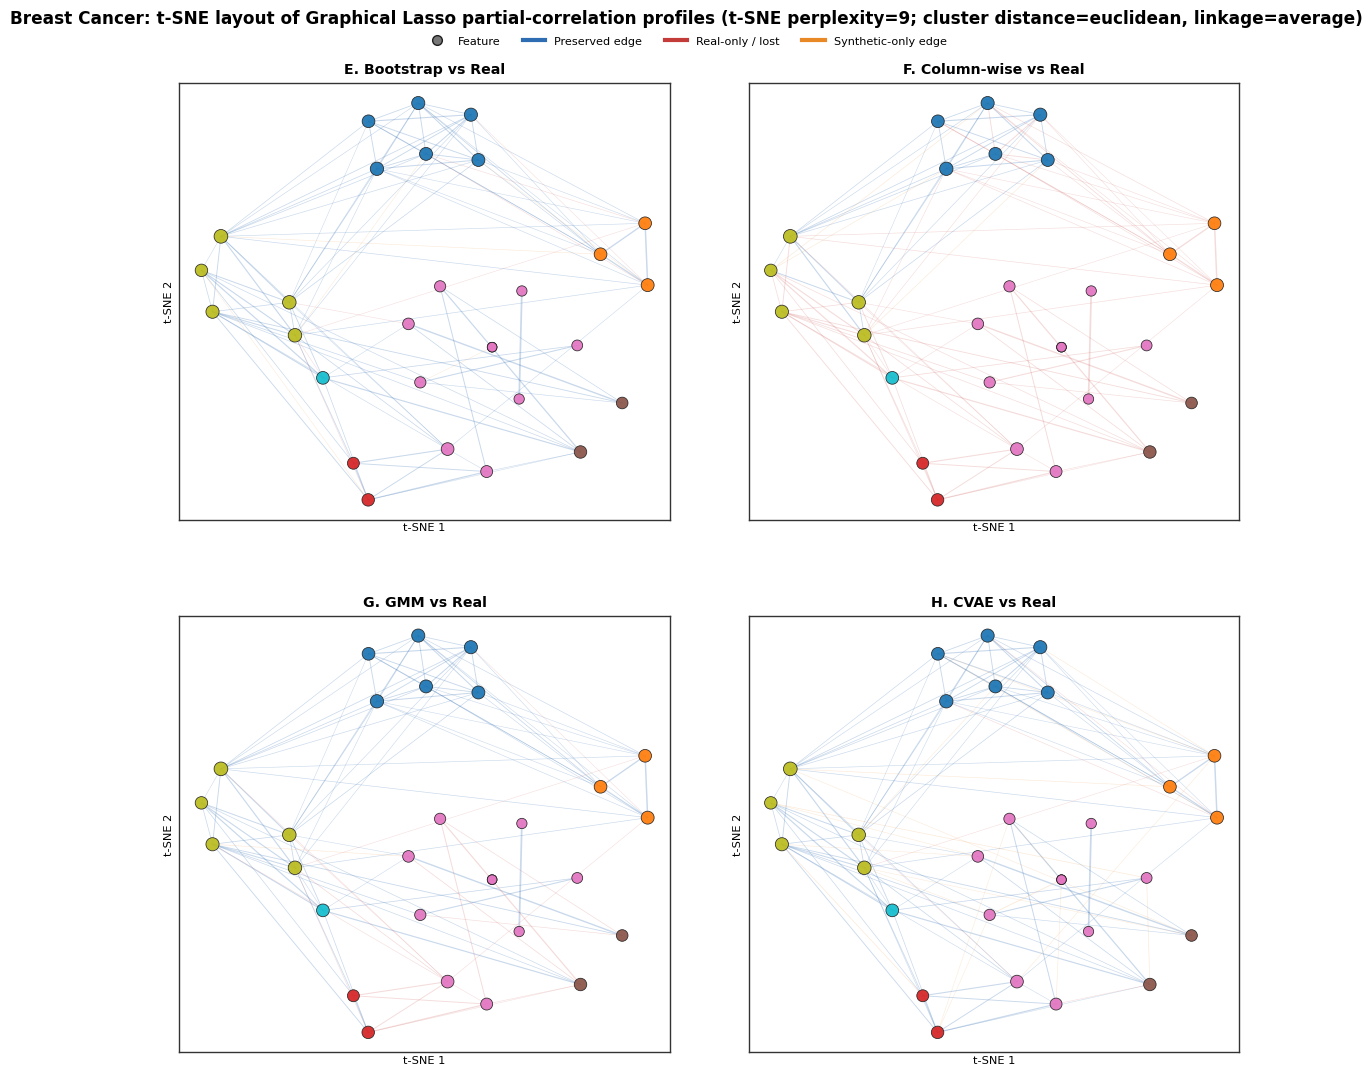

c:\Users\tonyt\Desktop\distinguishable_data\.venv\Lib\site-packages\sklearn\covariance\_graph_lasso.py:199: ConvergenceWarning: graphical_lasso: did not converge after 1000 iteration: dual gap: -1.299e-04
  warnings.warn(


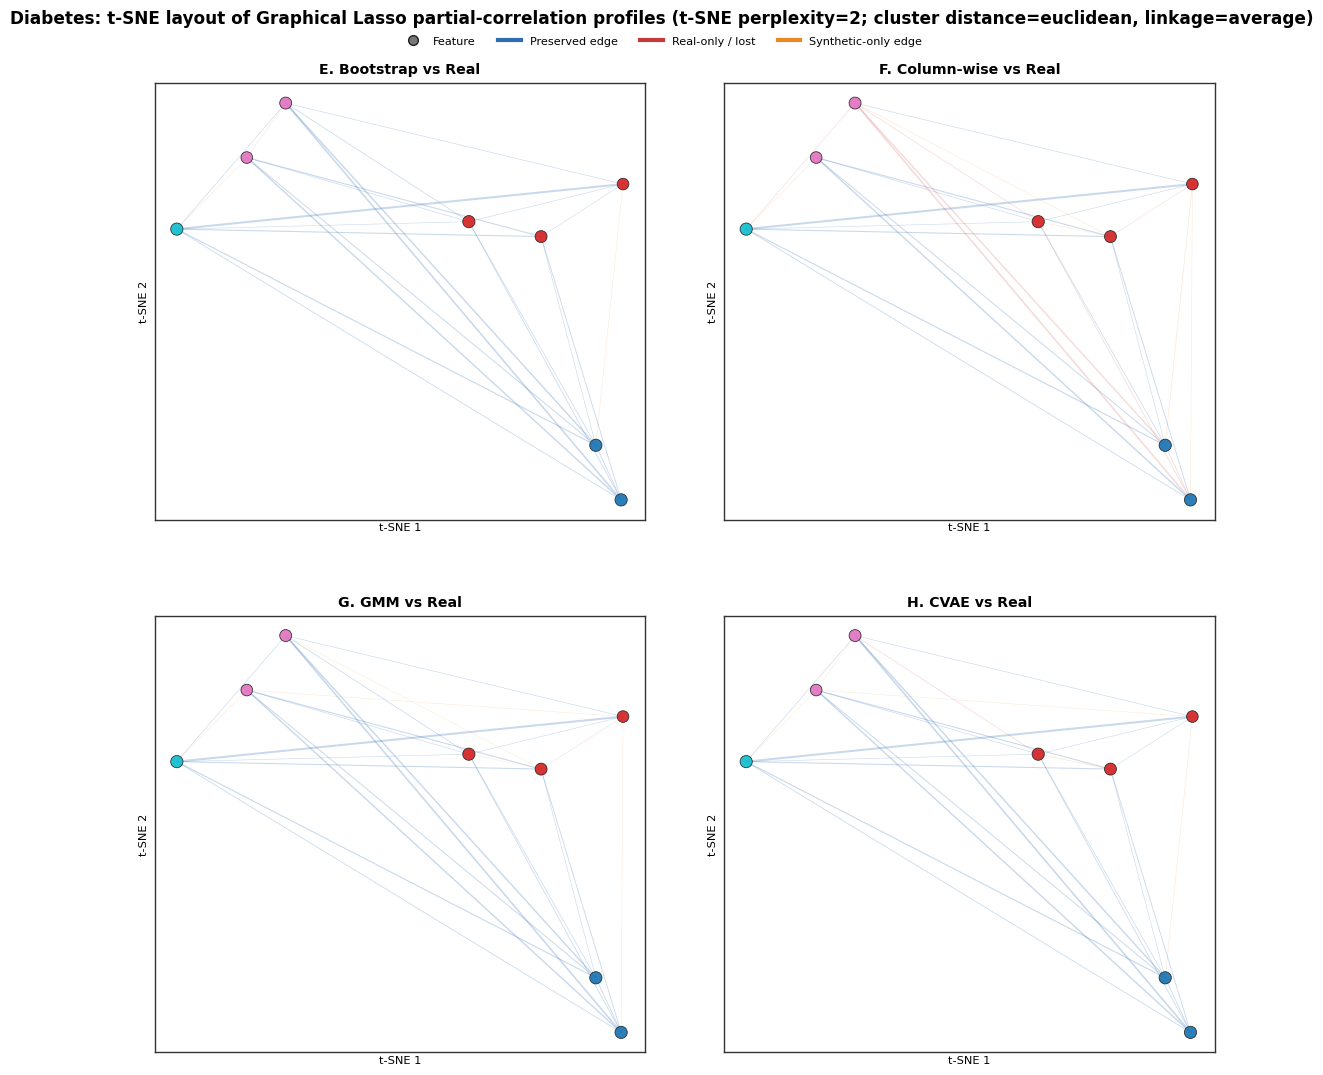

In [124]:
baseline_tsne = {}
for dataset_name in revision_config.DATASET_ORDER:
    result = figure4_graphical_lasso.plot_figure4_tsne_analysis_supplement(
        dataset_name,
        cluster_metric="euclidean",
        cluster_linkage="average",
    )
    baseline_tsne[dataset_name] = result
    revision_display.display_result_once(result)

### Baseline Cluster Sizes

This summarizes the feature-cluster sizes induced by the baseline Euclidean profile-distance clustering. It does not use synthetic data; it is only about clustering real Graphical Lasso partial-correlation profiles.

In [125]:
def real_profile_matrix(dataset_name):
    X = np.asarray(figure4_real_data[dataset_name], dtype=float)
    theta = figure4_graphical_lasso_plots.fit_glasso_precision(X, figure4_graphical_lasso.FIGURE4_ALPHAS[dataset_name])
    partial = figure4_graphical_lasso_plots.precision_to_partial_corr(theta)
    profiles = partial.copy()
    np.fill_diagonal(profiles, 0.0)
    profiles = StandardScaler().fit_transform(profiles)
    return partial, profiles


def heuristic_k(n_features, max_clusters=7):
    k = int(min(max_clusters, max(3, round(np.sqrt(n_features) * 1.35))))
    return min(k, max(2, n_features // 2))


def cluster_labels_for_profiles(profiles, metric="euclidean", linkage_method="average", max_clusters=7):
    n_features = profiles.shape[0]
    k = heuristic_k(n_features, max_clusters=max_clusters)
    distances = pdist(profiles, metric=metric)
    linkage = hierarchy.linkage(distances, method=linkage_method)
    return hierarchy.fcluster(linkage, t=k, criterion="maxclust")


def cluster_size_summary(metric="euclidean", linkage_method="average"):
    rows = []
    for dataset_name in revision_config.DATASET_ORDER:
        _, profiles = real_profile_matrix(dataset_name)
        labels = cluster_labels_for_profiles(profiles, metric=metric, linkage_method=linkage_method)
        counts = pd.Series(labels).value_counts().sort_values(ascending=False).to_list()
        rows.append({
            "dataset": dataset_name,
            "metric": metric,
            "linkage": linkage_method,
            "n_features": profiles.shape[0],
            "requested_k": heuristic_k(profiles.shape[0]),
            "actual_k": len(set(labels)),
            "largest_cluster": counts[0],
            "cluster_sizes": ",".join(map(str, counts)),
        })
    return pd.DataFrame(rows)

baseline_cluster_sizes = cluster_size_summary(metric="euclidean", linkage_method="average")
display(baseline_cluster_sizes)

,dataset,metric,linkage,n_features,requested_k,actual_k,largest_cluster,cluster_sizes
0,HIV,euclidean,average,63,7,7,55,"55,2,2,1,1,1,1"
1,Breast Cancer,euclidean,average,30,7,7,11,"11,6,5,3,2,2,1"
2,Diabetes,euclidean,average,8,4,4,3,"3,2,2,1"


## Changing Distance

Everything in this section keeps the same real Graphical Lasso partial-correlation profiles and average-linkage clustering, but changes the distance metric between feature profiles.

This asks whether sparse dependency profiles should be clustered by absolute coordinate distance (`euclidean`) or by profile direction/pattern (`cosine` or `correlation`).

### Cosine Profile Distance

Cosine distance compares the direction of two sparse dependency-profile vectors. This can separate features that connect to similar biomarker neighborhoods even when their absolute edge strengths differ.

c:\Users\tonyt\Desktop\distinguishable_data\.venv\Lib\site-packages\sklearn\covariance\_graph_lasso.py:199: ConvergenceWarning: graphical_lasso: did not converge after 1000 iteration: dual gap: -1.299e-04
  warnings.warn(


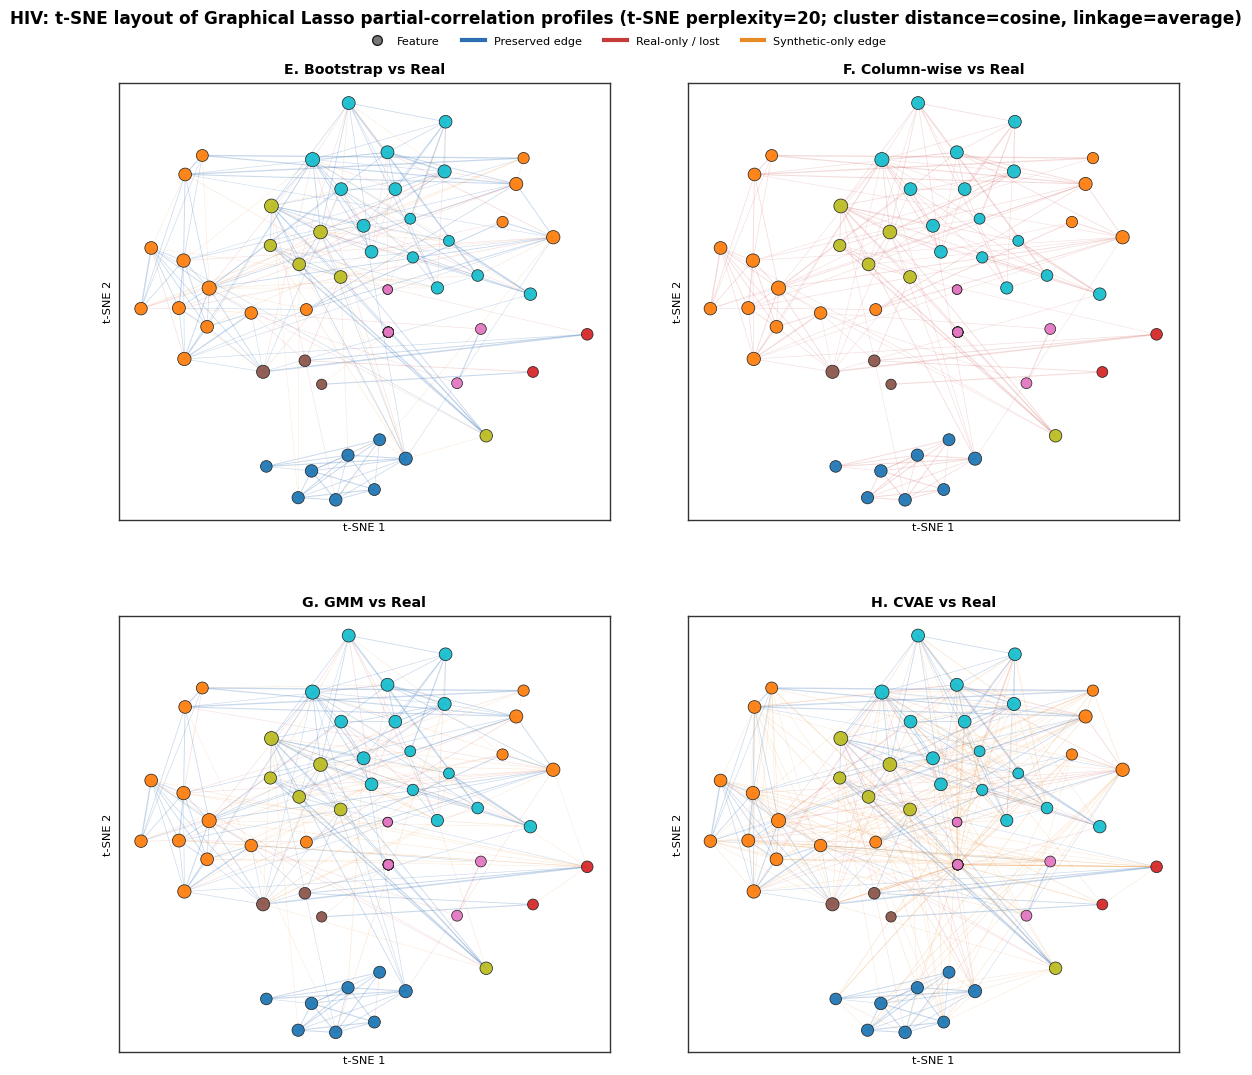

c:\Users\tonyt\Desktop\distinguishable_data\.venv\Lib\site-packages\sklearn\covariance\_graph_lasso.py:199: ConvergenceWarning: graphical_lasso: did not converge after 1000 iteration: dual gap: -1.299e-04
  warnings.warn(


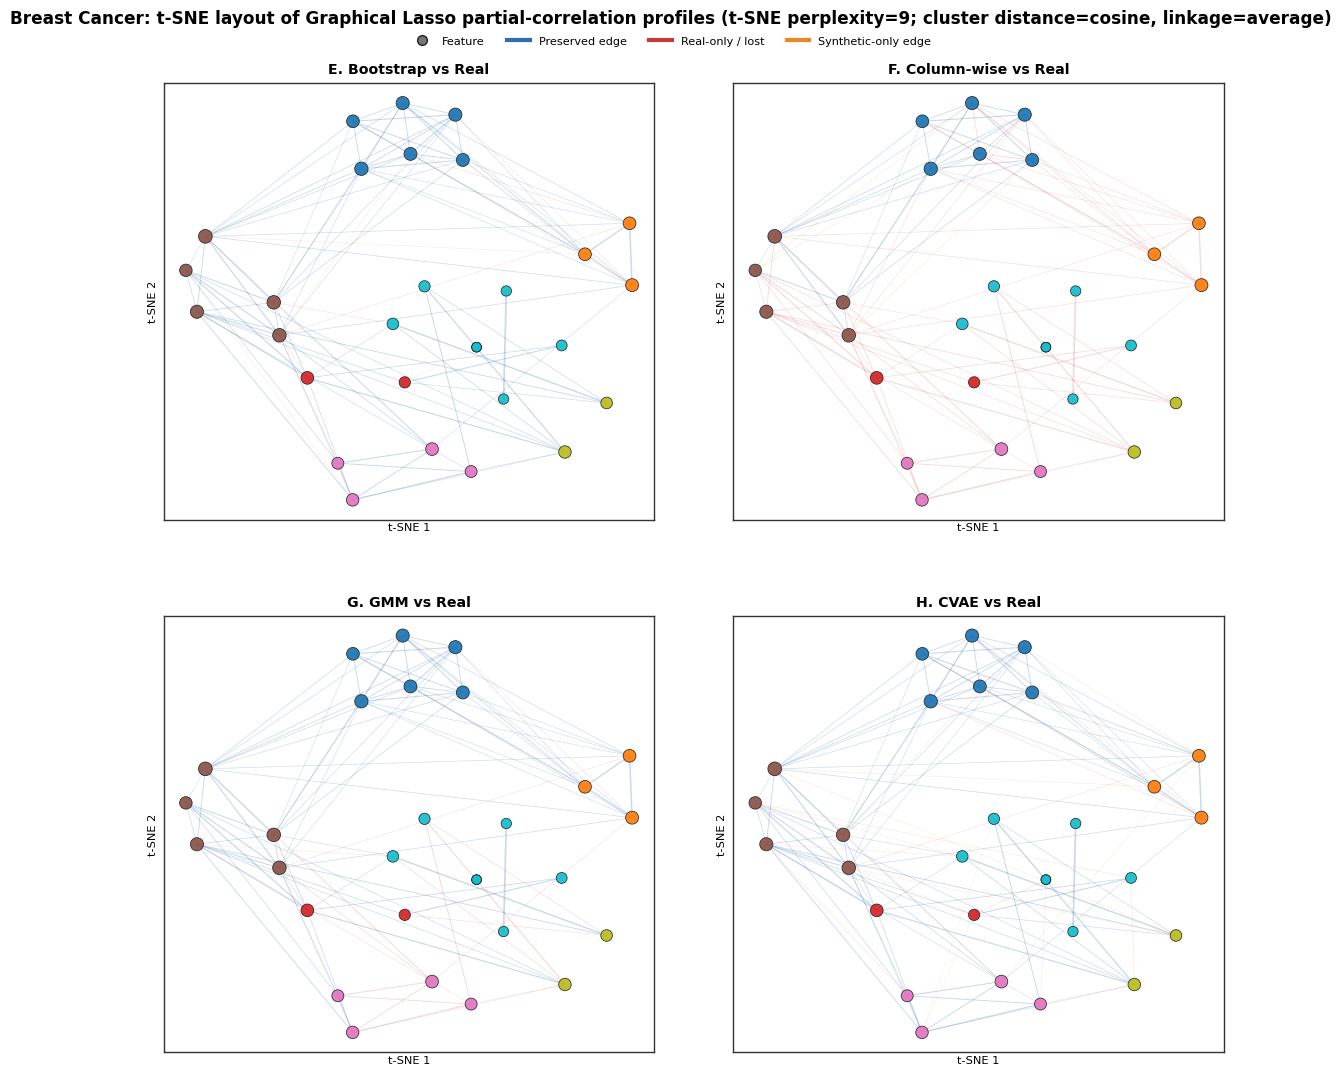

c:\Users\tonyt\Desktop\distinguishable_data\.venv\Lib\site-packages\sklearn\covariance\_graph_lasso.py:199: ConvergenceWarning: graphical_lasso: did not converge after 1000 iteration: dual gap: -1.299e-04
  warnings.warn(


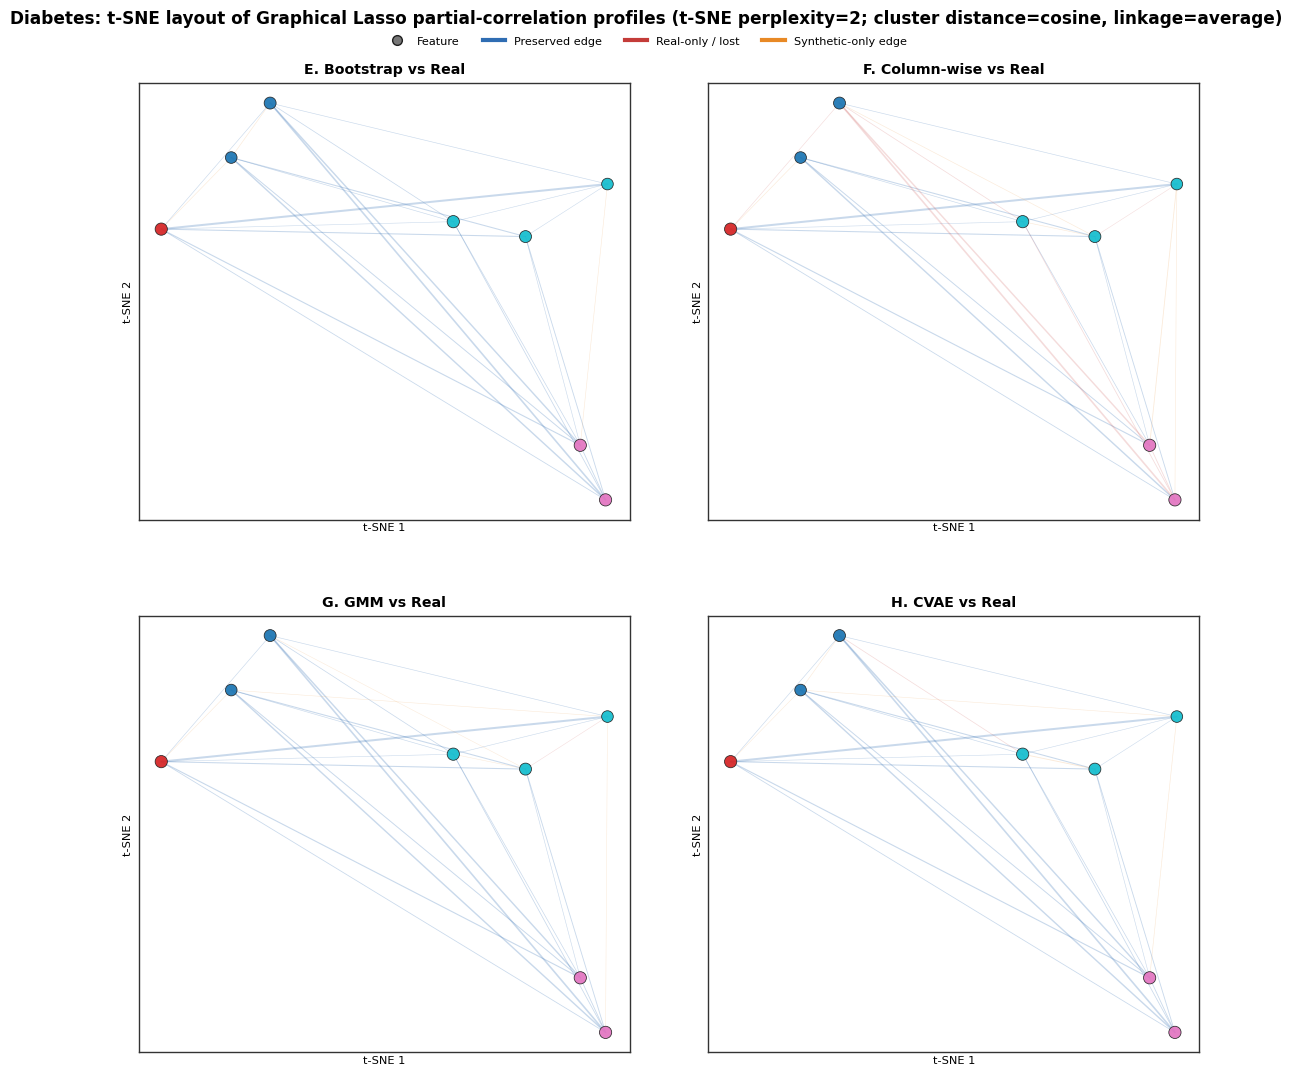

In [126]:
cosine_tsne = {}
for dataset_name in revision_config.DATASET_ORDER:
    result = figure4_graphical_lasso.plot_figure4_tsne_analysis_supplement(
        dataset_name,
        cluster_metric="cosine",
        cluster_linkage="average",
    )
    cosine_tsne[dataset_name] = result
    revision_display.display_result_once(result)

### Compare Baseline vs Cosine Cluster Sizes

The same requested cluster count is used for both rows within each dataset. A large change in cluster sizes means the distance metric materially changes the grouping.

In [127]:
distance_cluster_sizes = pd.concat([
    cluster_size_summary(metric="euclidean", linkage_method="average"),
    cluster_size_summary(metric="cosine", linkage_method="average"),
    cluster_size_summary(metric="correlation", linkage_method="average"),
], ignore_index=True)

display(distance_cluster_sizes.sort_values(["dataset", "metric"]))

,dataset,metric,linkage,n_features,requested_k,actual_k,largest_cluster,cluster_sizes
7,Breast Cancer,correlation,average,30,7,7,7,"7,6,4,4,4,3,2"
4,Breast Cancer,cosine,average,30,7,7,8,"8,6,5,4,3,2,2"
1,Breast Cancer,euclidean,average,30,7,7,11,"11,6,5,3,2,2,1"
8,Diabetes,correlation,average,8,4,4,3,"3,2,2,1"
5,Diabetes,cosine,average,8,4,4,3,"3,2,2,1"
2,Diabetes,euclidean,average,8,4,4,3,"3,2,2,1"
6,HIV,correlation,average,63,7,7,23,"23,17,11,9,1,1,1"
3,HIV,cosine,average,63,7,7,15,"15,15,14,8,6,3,2"
0,HIV,euclidean,average,63,7,7,55,"55,2,2,1,1,1,1"


### Full Distance/Linkage Sensitivity Table

This grid tries several linkage methods, distance metrics, and requested cluster counts. `silhouette` is a rough separation score; higher is better, but it should be interpreted alongside cluster sizes and biological plausibility.

In [128]:
def cluster_sensitivity_table(max_requested_k=12):
    rows = []
    labels_by_dataset = {}
    settings = []
    for dataset_name in revision_config.DATASET_ORDER:
        _, profiles = real_profile_matrix(dataset_name)
        n_features = profiles.shape[0]
        settings.clear()
        labels_by_setting = {}
        for linkage_method in ["single", "complete", "average", "ward"]:
            for metric in ["euclidean", "cosine", "correlation"]:
                if linkage_method == "ward" and metric != "euclidean":
                    continue
                distances = pdist(profiles, metric=metric)
                if not np.all(np.isfinite(distances)) or np.allclose(distances, 0):
                    continue
                linkage = hierarchy.linkage(distances, method=linkage_method)
                for requested_k in range(3, min(max_requested_k, max(3, n_features - 1)) + 1):
                    labels = hierarchy.fcluster(linkage, t=requested_k, criterion="maxclust")
                    actual_k = len(set(labels))
                    counts = pd.Series(labels).value_counts().sort_values(ascending=False).to_list()
                    silhouette = np.nan
                    if 1 < actual_k < n_features:
                        silhouette = silhouette_score(
                            profiles,
                            labels,
                            metric=metric if linkage_method != "ward" else "euclidean",
                        )
                    key = (linkage_method, metric, requested_k)
                    labels_by_setting[key] = labels
                    rows.append({
                        "dataset": dataset_name,
                        "n_features": n_features,
                        "linkage": linkage_method,
                        "metric": metric,
                        "requested_k": requested_k,
                        "actual_k": actual_k,
                        "largest_cluster": counts[0],
                        "cluster_sizes": ",".join(map(str, counts)),
                        "silhouette": silhouette,
                    })
        baseline_key = ("average", "euclidean", heuristic_k(n_features))
        baseline_labels = labels_by_setting.get(baseline_key)
        if baseline_labels is not None:
            for row in rows:
                if row["dataset"] != dataset_name or row["requested_k"] != baseline_key[2]:
                    continue
                key = (row["linkage"], row["metric"], row["requested_k"])
                row["ari_to_baseline"] = adjusted_rand_score(baseline_labels, labels_by_setting[key])
    return pd.DataFrame(rows)

sensitivity = cluster_sensitivity_table()
sensitivity_path = EXPORT_DIR / "figure4_tsne_distance_sensitivity.csv"
sensitivity.to_csv(sensitivity_path, index=False)
print(f"Wrote {sensitivity_path}")

display(
    sensitivity
    .sort_values(["dataset", "silhouette"], ascending=[True, False])
    .groupby("dataset")
    .head(10)
)

Wrote c:\Users\tonyt\Desktop\distinguishable_data\data_synthesis\notebooks\revision_exports\figure4_tsne_distance_sensitivity.csv


,dataset,n_features,linkage,metric,requested_k,actual_k,largest_cluster,cluster_sizes,silhouette,ari_to_baseline
188,Breast Cancer,30,average,correlation,11,11,6,"6,5,3,2,2,2,2,2,2,2,2",0.427002,NaN
159,Breast Cancer,30,complete,correlation,12,12,6,"6,4,3,2,2,2,2,2,2,2,2,1",0.423933,NaN
189,Breast Cancer,30,average,correlation,12,12,6,"6,4,3,2,2,2,2,2,2,2,2,1",0.423933,NaN
149,Breast Cancer,30,complete,cosine,12,12,6,"6,4,3,2,2,2,2,2,2,2,2,1",0.419313,NaN
179,Breast Cancer,30,average,cosine,12,12,6,"6,4,3,3,2,2,2,2,2,2,1,1",0.411164,NaN
178,Breast Cancer,30,average,cosine,11,11,6,"6,5,3,3,2,2,2,2,2,2,1",0.405993,NaN
157,Breast Cancer,30,complete,correlation,10,10,6,"6,5,4,3,2,2,2,2,2,2",0.402899,NaN
187,Breast Cancer,30,average,correlation,10,10,6,"6,5,4,3,2,2,2,2,2,2",0.402899,NaN
158,Breast Cancer,30,complete,correlation,11,11,6,"6,4,4,3,2,2,2,2,2,2,1",0.398921,NaN
148,Breast Cancer,30,complete,cosine,11,11,6,"6,4,4,3,2,2,2,2,2,2,1",0.393489,NaN


### Same-k Average-Linkage Distance Comparison

This table is the simplest apples-to-apples comparison: same requested `k`, same average linkage, only the distance metric changes.

In [129]:
same_k_average = []
for dataset_name, sub in sensitivity.groupby("dataset", sort=False):
    k = heuristic_k(int(sub["n_features"].iloc[0]))
    same_k_average.append(
        sub[
            (sub["requested_k"] == k)
            & (sub["linkage"] == "average")
            & (sub["metric"].isin(["euclidean", "cosine", "correlation"]))
        ]
    )
same_k_average = pd.concat(same_k_average, ignore_index=True)
display(same_k_average[[
    "dataset",
    "metric",
    "requested_k",
    "actual_k",
    "largest_cluster",
    "cluster_sizes",
    "silhouette",
    "ari_to_baseline",
]])

,dataset,metric,requested_k,actual_k,largest_cluster,cluster_sizes,silhouette,ari_to_baseline
0,HIV,euclidean,7,7,55,"55,2,2,1,1,1,1",0.069040,1.000000
1,HIV,cosine,7,7,15,"15,15,14,8,6,3,2",0.193856,0.015379
2,HIV,correlation,7,7,23,"23,17,11,9,1,1,1",0.125168,-0.029883
3,Breast Cancer,euclidean,7,7,11,"11,6,5,3,2,2,1",0.190327,1.000000
4,Breast Cancer,cosine,7,7,8,"8,6,5,4,3,2,2",0.334736,0.749977
5,Breast Cancer,correlation,7,7,7,"7,6,4,4,4,3,2",0.326435,0.576177
6,Diabetes,euclidean,4,4,3,"3,2,2,1",0.279804,1.000000
7,Diabetes,cosine,4,4,3,"3,2,2,1",0.476183,1.000000
8,Diabetes,correlation,4,4,3,"3,2,2,1",0.411796,1.000000


## Changing t-SNE Perplexity

Everything in this section keeps the same high-dimensional feature clusters, but changes the t-SNE perplexity used to draw the 2D layout. This is useful for diagnosing layout artifacts, such as one profile cluster appearing as two separated orange islands in a single t-SNE panel. If a split moves around or disappears as perplexity changes, it is probably a projection artifact rather than a new cluster.

In [130]:
PERPLEXITY_DATASET = "HIV"
PERPLEXITY_DISTANCE = "cosine"
PERPLEXITY_LINKAGE = "average"
PERPLEXITIES = [10, 20, 30, 40, 50]

partial, profiles = real_profile_matrix(PERPLEXITY_DATASET)
cluster_labels = figure4_graphical_lasso_plots._profile_clusters(
    profiles,
    max_clusters=7,
    metric=PERPLEXITY_DISTANCE,
    linkage_method=PERPLEXITY_LINKAGE,
)
feature_names_for_plot = list(figure4_feature_names[PERPLEXITY_DATASET])

rows = []
for perplexity in PERPLEXITIES:
    coords, _, used_perplexity = figure4_graphical_lasso_plots._fit_profile_tsne(
        partial,
        seed=revision_config.SEED,
        perplexity=perplexity,
    )
    for feature_index, (x, y) in enumerate(coords):
        rows.append({
            "perplexity": int(used_perplexity),
            "feature_index": feature_index,
            "feature": feature_names_for_plot[feature_index],
            "tsne_1": x,
            "tsne_2": y,
            "profile_cluster": f"cluster {int(cluster_labels[feature_index])}",
            "cluster_id": int(cluster_labels[feature_index]),
        })
perplexity_df = pd.DataFrame(rows)

try:
    import plotly.express as px
    fig_perplexity = px.scatter(
        perplexity_df,
        x="tsne_1",
        y="tsne_2",
        color="profile_cluster",
        facet_col="perplexity",
        facet_col_wrap=3,
        hover_name="feature",
        hover_data={
            "feature_index": True,
            "profile_cluster": True,
            "cluster_id": False,
            "tsne_1": False,
            "tsne_2": False,
        },
        title=(
            f"{PERPLEXITY_DATASET}: t-SNE perplexity sensitivity | "
            f"clusters={PERPLEXITY_LINKAGE}+{PERPLEXITY_DISTANCE}"
        ),
        width=1150,
        height=820,
    )
    fig_perplexity.update_traces(marker=dict(size=8.5, opacity=0.86, line=dict(width=0.6, color="#222222")))
    fig_perplexity.update_xaxes(showgrid=False, zeroline=False, matches=None)
    fig_perplexity.update_yaxes(showgrid=False, zeroline=False, matches=None)
    fig_perplexity.show()
except Exception as exc:
    print(f"Plotly unavailable: {exc!r}")
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(2, 3, figsize=(13.5, 8.4))
    axes = axes.ravel()
    for ax, perplexity in zip(axes, PERPLEXITIES):
        sub = perplexity_df[perplexity_df["perplexity"] == perplexity]
        for cluster_name, group in sub.groupby("profile_cluster"):
            ax.scatter(group["tsne_1"], group["tsne_2"], s=34, label=cluster_name, alpha=0.86, edgecolor="#222222", linewidth=0.4)
        ax.set_title(f"perplexity={perplexity}")
        ax.set_xticks([])
        ax.set_yticks([])
    axes[-1].axis("off")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="center right", fontsize=8)
    fig.tight_layout(rect=(0, 0, 0.88, 1))
    plt.show()

display(perplexity_df.head())

,perplexity,feature_index,feature,tsne_1,tsne_2,profile_cluster,cluster_id
0,10,0,spikeProduction_D1D2,-8.002441,188.990219,cluster 5,5
1,10,1,spikeDecay_D1D2,-65.531883,71.935112,cluster 5,5
2,10,2,spikeProduction_D3,-12.988083,131.333969,cluster 5,5
3,10,3,spikeDecay_D3,-105.763672,136.505783,cluster 5,5
4,10,4,RBDProduction_D1D2,-61.564842,168.822998,cluster 5,5


### Preserved / Lost / Synthetic-Only Summary with Prominent Features and Support Counts

This is a single cluster-summary plot for the distance setting below. Each cluster label combines the prominent feature(s) with the support count for the synthetic method assigned to that cluster, shown as `method: matching features / cluster features`. Cluster boundaries are hidden here because dot color already encodes profile-cluster membership; avoiding hulls keeps nearby or interleaved t-SNE groups from looking like fuzzy regions.


c:\Users\tonyt\Desktop\distinguishable_data\.venv\Lib\site-packages\sklearn\covariance\_graph_lasso.py:199: ConvergenceWarning: graphical_lasso: did not converge after 1000 iteration: dual gap: -1.299e-04
  warnings.warn(


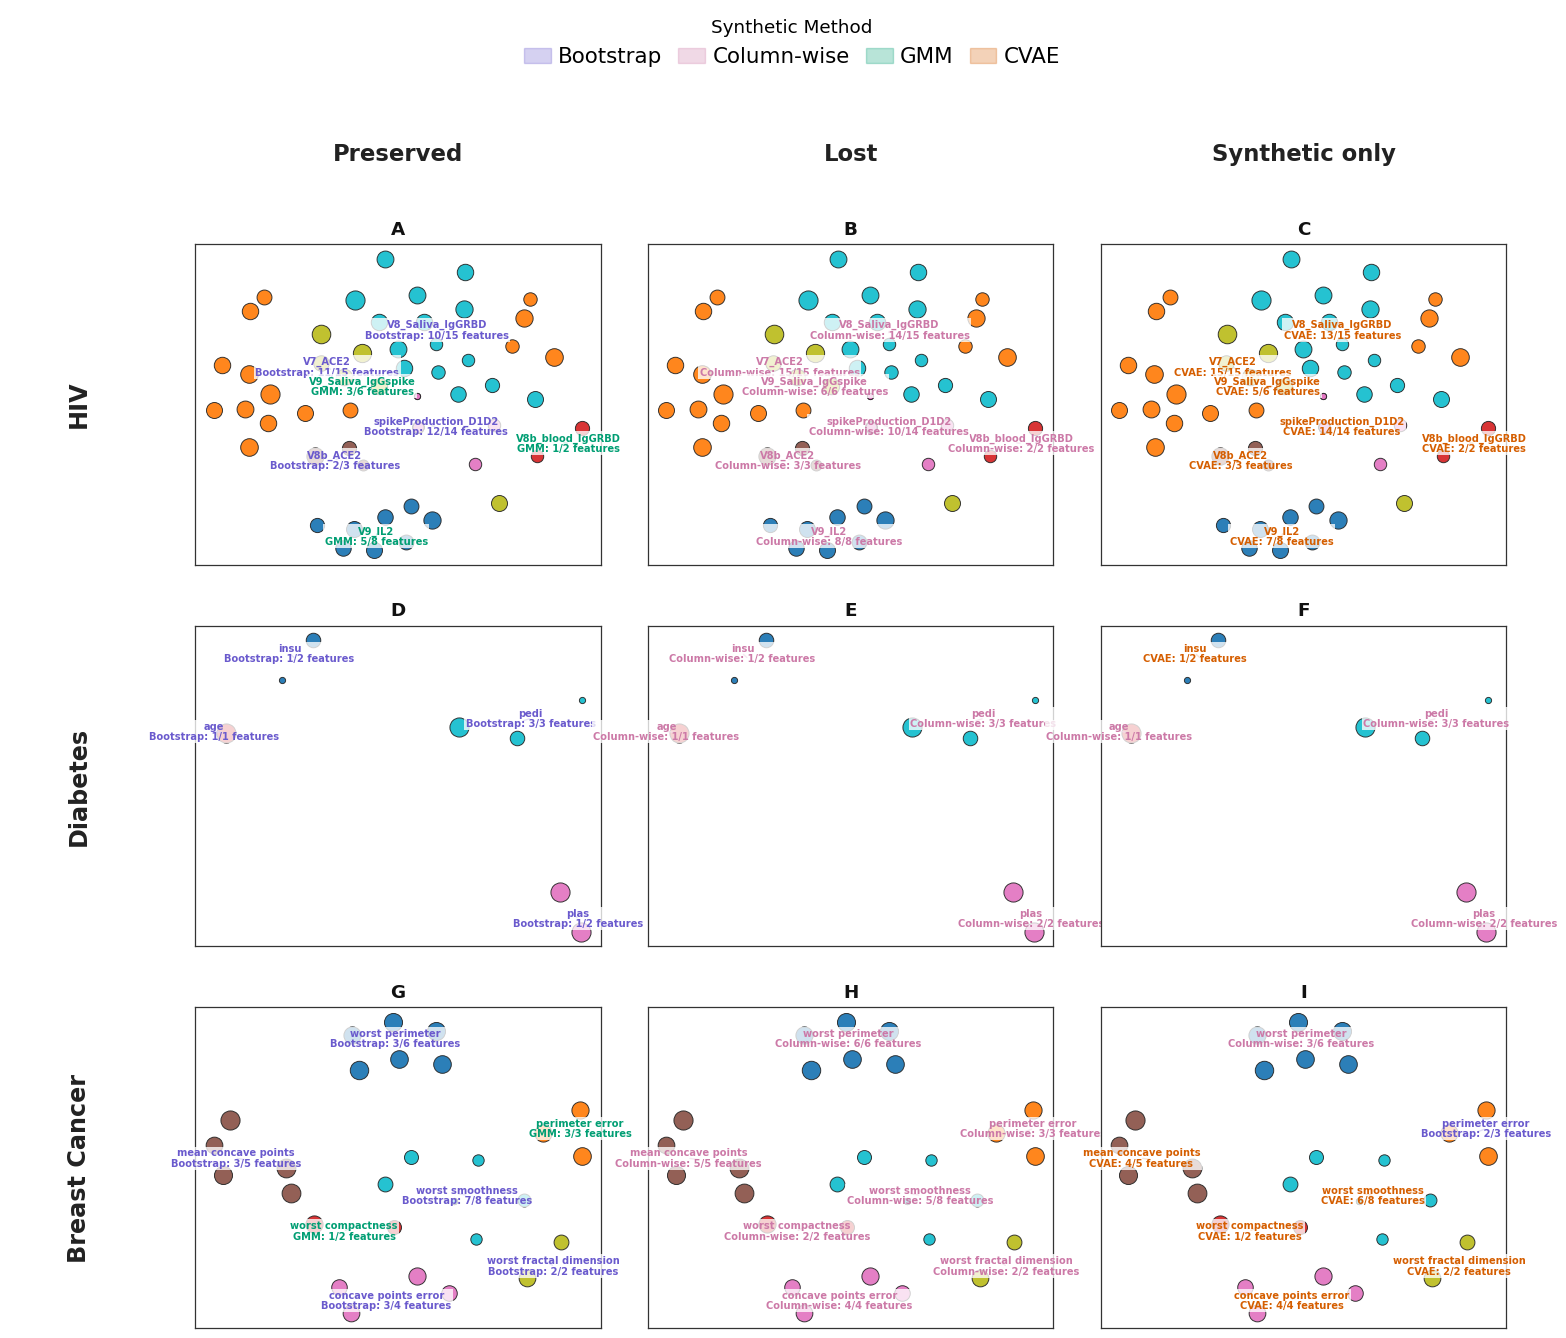

,dataset,panel,mode,cluster_id,method,n_features_matching_method,n_features,prominent_features
33,Breast Cancer,G,preserve,1,Bootstrap,3,6,worst perimeter
34,Breast Cancer,G,preserve,2,GMM,3,3,perimeter error
35,Breast Cancer,G,preserve,3,GMM,1,2,worst compactness
36,Breast Cancer,G,preserve,4,Bootstrap,3,5,mean concave points
37,Breast Cancer,G,preserve,5,Bootstrap,3,4,concave points error
38,Breast Cancer,G,preserve,6,Bootstrap,2,2,worst fractal dimension
39,Breast Cancer,G,preserve,7,Bootstrap,7,8,worst smoothness
40,Breast Cancer,H,lost,1,Column-wise,6,6,worst perimeter
41,Breast Cancer,H,lost,2,Column-wise,3,3,perimeter error
42,Breast Cancer,H,lost,3,Column-wise,2,2,worst compactness


In [131]:
SUMMARY_DISTANCE = "cosine"  # Options: "euclidean", "cosine", "correlation"
SUMMARY_LINKAGE = "average"
PROMINENT_FEATURES_PER_CLUSTER = 1

feature_support_summary = figure4_graphical_lasso_plots.plot_figure4_cluster_summary_grid(
    real_data=figure4_real_data,
    synthetic_data=figure4_synthetic_data,
    feature_names=figure4_feature_names,
    alphas=figure4_graphical_lasso.FIGURE4_ALPHAS,
    dataset_order=["HIV", "Diabetes", "Breast Cancer"],
    method_order=revision_config.METHOD_ORDER,
    cluster_metric=SUMMARY_DISTANCE,
    cluster_linkage=SUMMARY_LINKAGE,
    cluster_feature_label_top=PROMINENT_FEATURES_PER_CLUSTER,
    show_feature_support=True,
    cluster_blob_pad=0.0,
    cluster_boundary_style="none",
    cluster_fill_alpha=0.0,
    seed=revision_config.SEED,
)
feature_support_group_summary = feature_support_summary.group_summary

revision_display.display_result_once(feature_support_summary)
display(
    feature_support_group_summary[
        [
            "dataset",
            "panel",
            "mode",
            "cluster_id",
            "method",
            "n_features_matching_method",
            "n_features",
            "prominent_features",
        ]
    ].sort_values(["dataset", "panel", "cluster_id"])
)

## Euclidean vs Cosine Across t-SNE Perplexity

This plot compares the visual layout produced across perplexities 10-50 for both Euclidean-distance and cosine-distance profile clustering. 

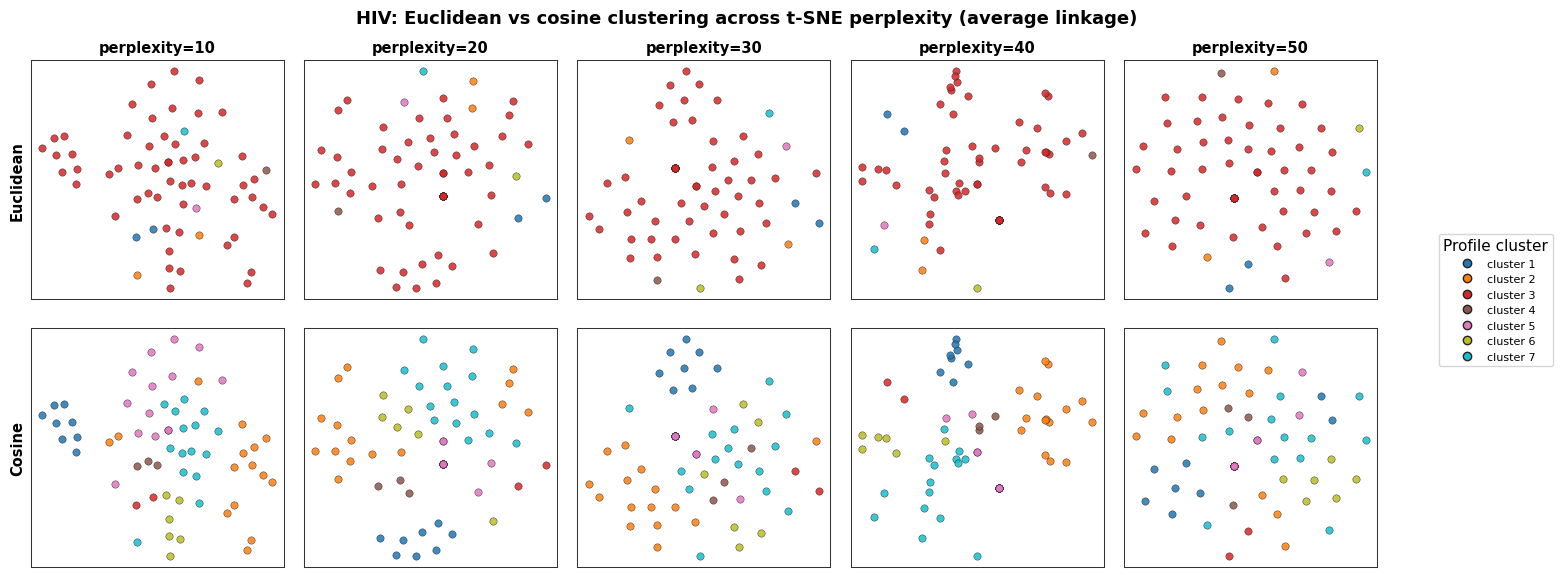

,metric,cluster_id,n_features
1,cosine,2,15
6,cosine,7,15
4,cosine,5,14
0,cosine,1,8
5,cosine,6,6
3,cosine,4,3
2,cosine,3,2
9,euclidean,3,55
7,euclidean,1,2
8,euclidean,2,2


In [134]:
COMPARE_DATASET = "HIV"  # Options: "HIV", "Breast Cancer", "Diabetes"
COMPARE_LINKAGE = "average"
COMPARE_PERPLEXITIES = [10, 20, 30, 40, 50]
COMPARE_METRICS = ["euclidean", "cosine"]

partial, profiles = real_profile_matrix(COMPARE_DATASET)
feature_names_compare = list(figure4_feature_names[COMPARE_DATASET])
compare_rows = []
for metric in COMPARE_METRICS:
    cluster_labels = figure4_graphical_lasso_plots._profile_clusters(
        profiles,
        max_clusters=7,
        metric=metric,
        linkage_method=COMPARE_LINKAGE,
    )
    for perplexity in COMPARE_PERPLEXITIES:
        coords, _, used_perplexity = figure4_graphical_lasso_plots._fit_profile_tsne(
            partial,
            seed=revision_config.SEED,
            perplexity=perplexity,
        )
        for feature_index, (x, y) in enumerate(coords):
            compare_rows.append({
                "metric": metric,
                "perplexity": int(used_perplexity),
                "feature_index": feature_index,
                "feature": feature_names_compare[feature_index],
                "tsne_1": x,
                "tsne_2": y,
                "cluster_id": int(cluster_labels[feature_index]),
                "profile_cluster": f"cluster {int(cluster_labels[feature_index])}",
            })
compare_perplexity_df = pd.DataFrame(compare_rows)

import matplotlib.pyplot as plt
cluster_ids = sorted(compare_perplexity_df["cluster_id"].unique())
colors = dict(zip(cluster_ids, plt.get_cmap("tab10")(np.linspace(0, 1, max(len(cluster_ids), 1)))))
fig, axes = plt.subplots(
    len(COMPARE_METRICS),
    len(COMPARE_PERPLEXITIES),
    figsize=(3.15 * len(COMPARE_PERPLEXITIES), 3.0 * len(COMPARE_METRICS)),
    constrained_layout=False,
)
axes = np.asarray(axes)
if axes.ndim == 1:
    axes = axes.reshape(len(COMPARE_METRICS), len(COMPARE_PERPLEXITIES))

for row_idx, metric in enumerate(COMPARE_METRICS):
    for col_idx, perplexity in enumerate(COMPARE_PERPLEXITIES):
        ax = axes[row_idx, col_idx]
        sub = compare_perplexity_df[
            (compare_perplexity_df["metric"] == metric)
            & (compare_perplexity_df["perplexity"] == perplexity)
        ]
        for cluster_id, group in sub.groupby("cluster_id", sort=True):
            ax.scatter(
                group["tsne_1"],
                group["tsne_2"],
                s=28,
                color=colors[cluster_id],
                edgecolor="#222222",
                linewidth=0.35,
                alpha=0.86,
            )
        if row_idx == 0:
            ax.set_title(f"perplexity={perplexity}", fontsize=10.5, weight="semibold")
        if col_idx == 0:
            ax.set_ylabel(metric.title(), fontsize=10.5, weight="semibold")
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.75)
            spine.set_edgecolor("#333333")

handles = [
    plt.Line2D([0], [0], marker="o", color="none", markerfacecolor=colors[cid], markeredgecolor="#222222", markersize=6, label=f"cluster {cid}")
    for cid in cluster_ids
]
fig.legend(handles=handles, loc="center right", bbox_to_anchor=(1.015, 0.5), fontsize=8, title="Profile cluster")
fig.suptitle(
    f"{COMPARE_DATASET}: Euclidean vs cosine clustering across t-SNE perplexity ({COMPARE_LINKAGE} linkage)",
    fontsize=13.0,
    weight="semibold",
    y=0.985,
)
fig.subplots_adjust(left=0.045, right=0.90, top=0.90, bottom=0.055, wspace=0.08, hspace=0.12)
plt.show()

display(
    compare_perplexity_df
    .groupby(["metric", "cluster_id"], as_index=False)
    .agg(n_features=("feature_index", "nunique"))
    .sort_values(["metric", "n_features"], ascending=[True, False])
)